# Capstone 20.1 — Notebook 1: Data Cleaning & Feature Engineering

**Author:** Sravanthi Gandu

**Research question:** *Can we forecast the volume of incoming Customer Provisioning
Tickets (CPT) and predict the resolution effort of each ticket at intake, in order to
anticipate workload and flag at-risk tickets before they breach SLA?*

This notebook loads the raw 2026 extract of the internal `cpt_active_tickets` table,
cleans it (missing values, duplicates, invalid records), engineers the features and the
target variable used downstream, and writes a tidy dataset for the EDA and modeling
notebooks.

> **Privacy note:** the source `assignee` field (employee email) was one-way hashed to
> `assignee_hash` during extraction. No customer or employee PII is present in this repo.

In [1]:
# Core libraries, imported and aliased conventionally
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)

## 1. Load the raw extract

In [2]:
# Date columns are parsed as UTC timestamps, then made tz-naive for clean arithmetic
DATE_COLS = [
    "create_date", "update_date", "due_date", "start_date",
    "end_date", "implementation_date", "effective_date",
]

raw = pd.read_csv("../data/cpt_active_tickets_2026.csv")
# format="ISO8601" handles the source's mixed sub-second precision robustly
for c in DATE_COLS:
    raw[c] = pd.to_datetime(raw[c], format="ISO8601", utc=True).dt.tz_localize(None)

print(f"Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head()

Raw shape: 44,299 rows x 24 columns


,ticket_id,create_date,update_date,due_date,start_date,end_date,implementation_date,effective_date,status,status_reason,type,order_type,order_reason,requestor_system,sourceofrecords,geo,country,market_segment,cloud,offer_family,offer_id,offer_quantity,acm_id,assignee_hash
0,198985,2026-01-01 00:00:47.478,2026-01-01 00:49:24.489,2026-01-01 08:00:00,2026-01-01 08:00:00,2026-07-17 07:00:00,NaT,2026-01-01 08:00:00,CLOSED,COMPLETED_MANUALLY,REGULAR,NEW_ORDER,NaN,Hoolihan,TIX,AMERICAS,CA,GOV,CREATIVE,CC_ALL_APPS,B2DB7770E30872F108BEEDE66C9349CE,9.0,4401171666,A_92f35598b7
1,198986,2026-01-01 00:00:51.484,2026-01-01 00:42:00.858,2024-11-14 08:00:00,2024-11-14 08:00:00,2025-11-13 08:00:00,NaT,2024-11-14 08:00:00,CLOSED,COMPLETED_MANUALLY,REGULAR,NEW_ORDER,906 Global 3pty,Hoolihan,TIX,AMERICAS,US,COM,DOCUMENT,ACROBAT,8920AA1BA9BA9E34E05EFCAE324701FE,14.0,4401124465,A_92f35598b7
2,198986,2026-01-01 00:00:51.484,2026-01-01 00:42:00.858,2024-11-14 08:00:00,2024-11-14 08:00:00,2025-11-13 08:00:00,NaT,2024-11-14 08:00:00,CLOSED,COMPLETED_MANUALLY,REGULAR,NEW_ORDER,906 Global 3pty,Hoolihan,TIX,AMERICAS,US,COM,DOCUMENT,ACROBAT,B685F1DAB145A3C1DE1987C7B32BDD51,98.0,4401124465,A_92f35598b7
3,198986,2026-01-01 00:00:51.484,2026-01-01 00:42:00.858,2024-11-14 08:00:00,2024-11-14 08:00:00,2025-11-13 08:00:00,NaT,2024-11-14 08:00:00,CLOSED,COMPLETED_MANUALLY,REGULAR,NEW_ORDER,906 Global 3pty,Hoolihan,TIX,AMERICAS,US,COM,OTHERS,CAPTIVATE,935E578545607CF9272844AD64F85819,2.0,4401124465,A_92f35598b7
4,198986,2026-01-01 00:00:51.484,2026-01-01 00:42:00.858,2024-11-14 08:00:00,2025-11-14 08:00:00,2026-11-13 08:00:00,NaT,2024-11-14 08:00:00,CLOSED,COMPLETED_MANUALLY,REGULAR,NEW_ORDER,906 Global 3pty,Hoolihan,TIX,AMERICAS,US,COM,DOCUMENT,ACROBAT,8920AA1BA9BA9E34E05EFCAE324701FE,14.0,4401124465,A_92f35598b7


In [3]:
# Column dtypes and non-null counts
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44299 entries, 0 to 44298
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ticket_id            44299 non-null  int64         
 1   create_date          44299 non-null  datetime64[ns]
 2   update_date          44299 non-null  datetime64[ns]
 3   due_date             32962 non-null  datetime64[ns]
 4   start_date           32961 non-null  datetime64[ns]
 5   end_date             32961 non-null  datetime64[ns]
 6   implementation_date  10136 non-null  datetime64[ns]
 7   effective_date       43995 non-null  datetime64[ns]
 8   status               44299 non-null  object        
 9   status_reason        44194 non-null  object        
 10  type                 44299 non-null  object        
 11  order_type           33057 non-null  object        
 12  order_reason         7300 non-null   object        
 13  requestor_system     44299 non-

## 2. Missing values

The extract is at **order-line-item** granularity, so several ticket-level date fields
are only populated once a ticket reaches the relevant stage. We quantify missingness
before deciding how to treat each column.

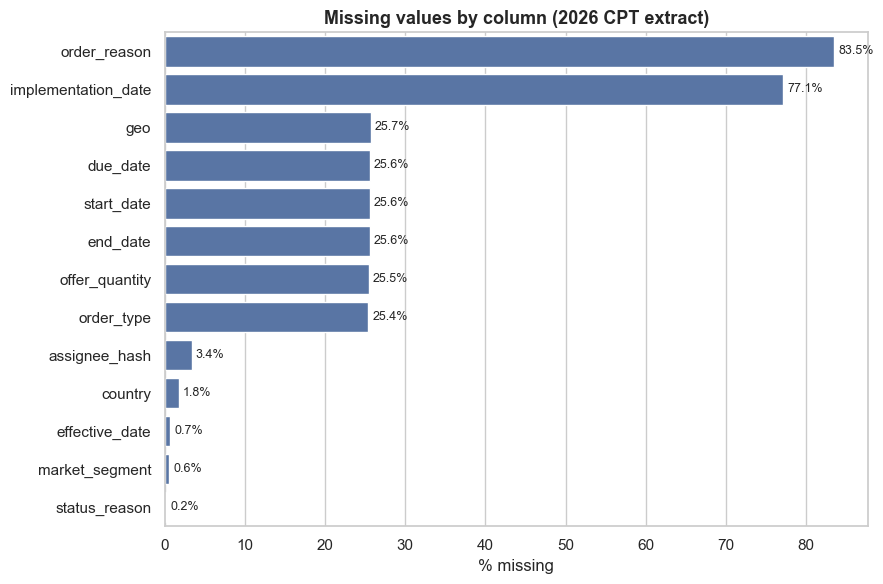

In [4]:
# Percentage of missing values per column, highest first
missing = (raw.isna().mean() * 100).round(1).sort_values(ascending=False)
missing_nonzero = missing[missing > 0]

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=missing_nonzero.values, y=missing_nonzero.index, color="#4C72B0", ax=ax)
ax.set_title("Missing values by column (2026 CPT extract)", fontsize=13, weight="bold")
ax.set_xlabel("% missing")
ax.set_ylabel("")
for i, v in enumerate(missing_nonzero.values):
    ax.text(v + 0.5, i, f"{v}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Remove duplicate rows

A single ticket can legitimately appear on multiple rows (one per offer line item), so we
only drop **fully identical** rows, which are true duplicates introduced by the source
system's change-data-capture.

In [5]:
before = len(raw)
df = raw.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df):,} exact-duplicate rows -> {len(df):,} rows remain")

Dropped 1,692 exact-duplicate rows -> 42,607 rows remain


## 4. Feature engineering

We derive the modeling target and a set of **intake-time** features (all knowable the
moment a ticket is created), so nothing leaks future information into later models.

* `resolution_days` — target: calendar days from `create_date` to `implementation_date`.
* `is_resolved` — whether the ticket has an implementation date yet.
* `create_month`, `create_week`, `create_dow`, `create_hour` — seasonality signals.
* `line_items_per_ticket` — size/complexity proxy for a ticket.

In [6]:
# Target: resolution duration in days (only defined for resolved tickets)
df["resolution_days"] = (
    (df["implementation_date"] - df["create_date"]).dt.total_seconds() / 86400
)
df["is_resolved"] = df["implementation_date"].notna()

# Intake-time calendar features from create_date
df["create_date_only"] = df["create_date"].dt.date
df["create_month"] = df["create_date"].dt.month
df["create_week"] = df["create_date"].dt.isocalendar().week.astype("int")
df["create_dow"] = df["create_date"].dt.dayofweek          # 0 = Monday
df["create_hour"] = df["create_date"].dt.hour

# Ticket size: how many offer line items share the same ticket_id
df["line_items_per_ticket"] = df.groupby("ticket_id")["ticket_id"].transform("count")

df[["ticket_id", "create_date", "implementation_date",
    "resolution_days", "is_resolved", "create_month", "line_items_per_ticket"]].head()

,ticket_id,create_date,implementation_date,resolution_days,is_resolved,create_month,line_items_per_ticket
0,198985,2026-01-01 00:00:47.478,NaT,NaN,False,1,1
1,198986,2026-01-01 00:00:51.484,NaT,NaN,False,1,9
2,198986,2026-01-01 00:00:51.484,NaT,NaN,False,1,9
3,198986,2026-01-01 00:00:51.484,NaT,NaN,False,1,9
4,198986,2026-01-01 00:00:51.484,NaT,NaN,False,1,9


### 4a. Handle invalid resolution durations

A small number of rows have an `implementation_date` **before** the `create_date`
(negative duration) — a data-entry / back-dating artifact. These are set to missing so
they do not contaminate the target.

In [7]:
neg = (df["resolution_days"] < 0).sum()
print(f"Negative-duration rows set to NaN: {neg:,}")
df.loc[df["resolution_days"] < 0, "resolution_days"] = np.nan

# Refresh the resolved flag against the cleaned target
df["is_resolved"] = df["resolution_days"].notna()
print(f"Resolved tickets with a valid duration: {df['is_resolved'].sum():,}")
df["resolution_days"].describe(percentiles=[.25, .5, .75, .9, .95]).round(2)

Negative-duration rows set to NaN: 3,858
Resolved tickets with a valid duration: 5,575


count    5575.00
mean      120.76
std       250.60
min         0.04
25%         9.54
50%        15.25
75%        53.97
90%       379.24
95%       730.72
max      1780.26
Name: resolution_days, dtype: float64

## 5. Outlier analysis

`resolution_days` is extremely right-skewed (a median around two weeks but a tail past a
year). We visualize the raw vs. log-scaled distribution and flag statistical outliers
with the IQR rule rather than deleting them — long-running tickets are exactly the
"at-risk" cases the project cares about.

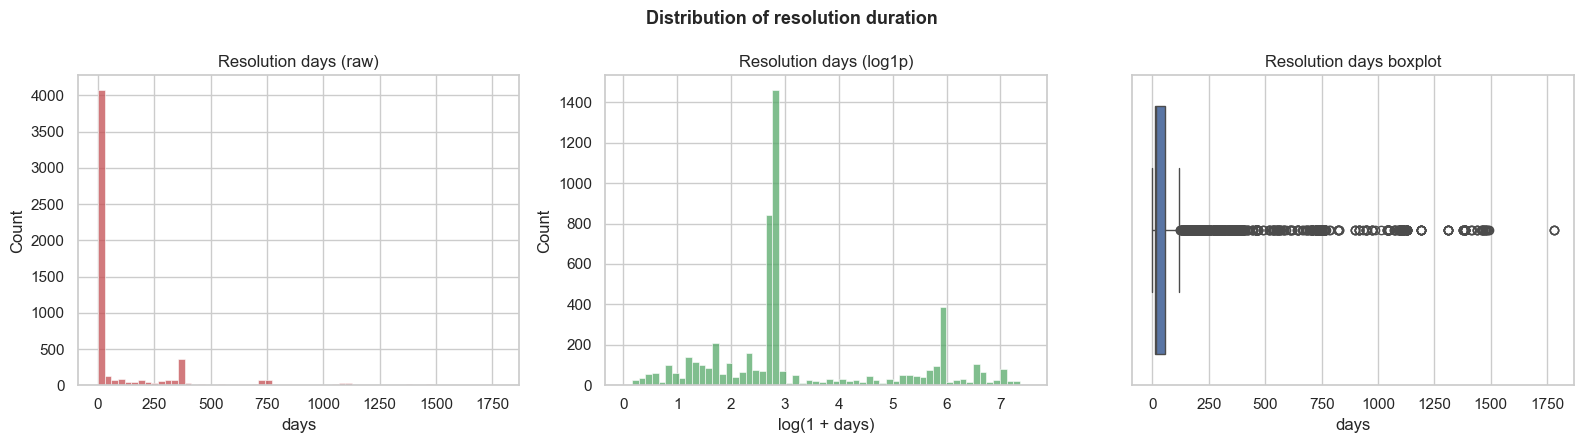

In [8]:
resolved = df.loc[df["is_resolved"], "resolution_days"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(resolved, bins=60, color="#C44E52", ax=axes[0])
axes[0].set_title("Resolution days (raw)")
axes[0].set_xlabel("days")

sns.histplot(np.log1p(resolved), bins=60, color="#55A868", ax=axes[1])
axes[1].set_title("Resolution days (log1p)")
axes[1].set_xlabel("log(1 + days)")

sns.boxplot(x=resolved, color="#4C72B0", ax=axes[2])
axes[2].set_title("Resolution days boxplot")
axes[2].set_xlabel("days")

plt.suptitle("Distribution of resolution duration", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

In [9]:
# IQR-based outlier flag (kept, not removed)
q1, q3 = resolved.quantile(0.25), resolved.quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
df["is_duration_outlier"] = df["resolution_days"] > upper
print(f"IQR upper fence: {upper:.1f} days")
print(f"Flagged {df['is_duration_outlier'].sum():,} long-running outlier tickets "
      f"({df['is_duration_outlier'].mean()*100:.1f}% of all rows)")

IQR upper fence: 120.6 days
Flagged 1,220 long-running outlier tickets (2.9% of all rows)


## 6. Impute categorical fields

Categorical columns that are genuinely unknown are filled with the explicit label
`"UNKNOWN"` so that "missing" becomes an informative category the models can use, instead
of silently dropping rows.

In [10]:
CAT_COLS = [
    "status", "status_reason", "type", "order_type", "order_reason",
    "requestor_system", "sourceofrecords", "geo", "country",
    "market_segment", "cloud", "offer_family",
]
df[CAT_COLS] = df[CAT_COLS].fillna("UNKNOWN")

# Numeric offer_quantity: median imputation (skewed, so median over mean)
df["offer_quantity"] = df["offer_quantity"].fillna(df["offer_quantity"].median())

print("Remaining missing values in key columns:")
print(df[CAT_COLS + ["offer_quantity"]].isna().sum().sum(), "-> all imputed")

Remaining missing values in key columns:
0 -> all imputed


## 7. Save the cleaned dataset

In [11]:
OUT = "../data/cpt_clean.csv"
df.to_csv(OUT, index=False)
print(f"Saved cleaned data: {df.shape[0]:,} rows x {df.shape[1]} columns -> {OUT}")

Saved cleaned data: 42,607 rows x 33 columns -> ../data/cpt_clean.csv


## Summary

* Loaded **44,299** raw 2026 line items and removed exact duplicates.
* Engineered the target (`resolution_days`) and intake-time features
  (calendar parts, ticket size).
* Corrected negative durations, flagged (but retained) long-running outliers, and
  imputed missing categoricals as `"UNKNOWN"`.
* Wrote `data/cpt_clean.csv` for the EDA and baseline-model notebooks.

**Next:** [02 — Exploratory Data Analysis](02_exploratory_data_analysis.ipynb)